# 06 — Final Analysis & Production Prompt Selection

Az utolsó notebookban nem újabb promptot keresünk. A cél az, hogy a már lefuttatott benchmark alapján **mérnöki döntést** hozzunk. A legmagasabb F1 fontos, de productionban a reliability, token usage, cost és P95 latency is számít.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "02_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")

Project root: <PROJECT_ROOT>


## 0/A. A production döntés mindig provider-specifikus

A `Best Quality` vagy `Best Production Choice` cím csak az adott provider/model benchmarkon belül értelmezhető. Például a `groq + qwen/...` P5 eredménye és az `ollama + llama...` P5 eredménye két külön kísérlet.

A report summary tartalmazza a `provider` és `model` oszlopot is, hogy ez később se legyen összekeverhető.


## 1. Leaderboard betöltése

In [2]:
import pandas as pd

summary_path = PROJECT_ROOT / "07_outputs/results/benchmark_summary.csv"
if not summary_path.exists():
    raise FileNotFoundError("Run 05_scripts/07_generate_report.py first.")

summary = pd.read_csv(summary_path).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(summary)


,requests,correct_count,incorrect_count,invalid_output_count,api_error_count,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,invalid_output_rate,output_contract_valid_rate,invalid_json_rate,json_grammar_valid_rate,error_rate,mean_input_tokens,mean_output_tokens,mean_total_tokens,total_input_tokens,total_output_tokens,total_tokens,tokens_per_correct_prediction,mean_latency_seconds,median_latency_seconds,p50_latency_seconds,p95_latency_seconds,p99_latency_seconds,total_latency_seconds,sequential_throughput_rps,mean_cost_usd,cost_per_1000_requests_usd,benchmark_cost_usd,cost_per_correct_prediction_usd,mean_branch_count,provider,model,strategy,temperature,top_p,top_k,token_source,latency_source,macro_f1_ci_low,macro_f1_ci_high,absolute_f1_improvement_vs_p0,relative_f1_improvement_vs_p0_pct,token_overhead_vs_p0_pct,latency_overhead_vs_p0_pct,invalid_output_reduction_vs_p0_pp
0,300.0,284.0,16.0,0.0,0.0,0.946667,0.947522,0.946667,0.946599,0.946599,0.000000,1.000000,NaN,NaN,0.0,1388.460000,3.046667,1391.506667,416538.0,914.0,417452.0,1469.901408,1.520574,1.52190,1.52190,1.590605,1.612003,456.1722,0.657646,0.0,0.0,0.0,0.0,3.0,mock,mock-prompt-sensitive-simulator-v2,p14_tree_branch_vote,0.0,1.0,40,estimated_mock,simulated_mock,0.920880,0.969377,0.293317,44.898891,1283.711757,400.158795,10.000000
1,300.0,275.0,25.0,0.0,0.0,0.916667,0.922594,0.916667,0.917515,0.917515,0.000000,1.000000,0.00,1.00,0.0,1595.210000,12.000000,1607.210000,478563.0,3600.0,482163.0,1753.320000,1.049916,1.04975,1.04975,1.082600,1.088400,314.9747,0.952457,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p16_full_advanced_template,0.0,1.0,40,estimated_mock,simulated_mock,0.883127,0.946595,0.264232,40.446882,1498.206769,240.418842,10.000000
2,300.0,268.0,32.0,0.0,0.0,0.893333,0.898330,0.893333,0.894515,0.894515,0.000000,1.000000,NaN,NaN,0.0,464.903333,25.000000,489.903333,139471.0,7500.0,146971.0,548.399254,0.788863,0.78815,0.78815,0.820710,0.825701,236.6589,1.267647,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p13_reasoning_model,0.0,1.0,40,estimated_mock,simulated_mock,0.859018,0.928096,0.241233,36.926207,387.159004,158.068675,10.000000
3,300.0,251.0,49.0,4.0,0.0,0.836667,0.853710,0.836667,0.844015,0.844015,0.013333,0.986667,NaN,NaN,0.0,1332.736667,1.093333,1333.830000,399821.0,328.0,400149.0,1594.219124,0.851766,0.85240,0.85240,0.887315,0.891907,255.5299,1.174031,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p5_decision_policy,0.0,1.0,40,estimated_mock,simulated_mock,0.803720,0.882243,0.190733,29.196038,1226.358182,179.012326,8.666667
4,300.0,250.0,50.0,0.0,0.0,0.833333,0.838115,0.833333,0.834862,0.834862,0.000000,1.000000,0.00,1.00,0.0,313.886667,12.000000,325.886667,94166.0,3600.0,97766.0,391.064000,0.462568,0.46375,0.46375,0.493810,0.500503,138.7705,2.161843,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p15_grammar_constrained,0.0,1.0,40,estimated_mock,simulated_mock,0.791219,0.873012,0.181580,27.794951,224.061122,55.276398,10.000000
5,300.0,247.0,53.0,0.0,0.0,0.823333,0.844088,0.823333,0.826353,0.826353,0.000000,1.000000,0.00,1.00,0.0,1313.580000,12.000000,1325.580000,394074.0,3600.0,397674.0,1610.016194,0.870355,0.87165,0.87165,0.902725,0.909225,261.1064,1.148957,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p7_structured_output,0.0,1.0,40,estimated_mock,simulated_mock,0.779354,0.867150,0.173070,26.492395,1218.154397,183.857933,10.000000
6,300.0,242.0,58.0,9.0,0.0,0.806667,0.843613,0.806667,0.821044,0.821044,0.030000,0.970000,0.03,0.97,0.0,1359.653333,11.910000,1371.563333,407896.0,3573.0,411469.0,1700.285124,0.863370,0.86215,0.86215,0.894540,0.900005,259.0109,1.158252,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p6_json,0.0,1.0,40,estimated_mock,simulated_mock,0.777314,0.861138,0.167761,25.679727,1263.880142,181.284196,7.000000
7,300.0,244.0,56.0,2.0,0.0,0.813333,0.833533,0.813333,0.818540,0.818540,0.006667,0.993333,NaN,NaN,0.0,1316.140000,1.046667,1317.186667,39484

## 2. Best Quality

A quality winner a legmagasabb Macro F1-et elérő prompt. Ez az első kérdés, de **nem az utolsó**.

In [3]:
quality_winner = summary.iloc[0]
print("Best Quality:", quality_winner["strategy"])
print("Macro F1:", round(float(quality_winner["macro_f1"]), 4))
print("95% CI:", round(float(quality_winner["macro_f1_ci_low"]), 4), "-", round(float(quality_winner["macro_f1_ci_high"]), 4))


Best Quality: p14_tree_branch_vote
Macro F1: 0.9466
95% CI: 0.9209 - 0.9694


## 3. Quality vs baseline

A fontos szám nem csak a végső F1, hanem az, hogy mekkora **abszolút javulást** kaptunk P0-hoz képest.

In [4]:
baseline_row = summary[summary["strategy"] == "p0_zero_shot"].iloc[0]
comparison = summary[["strategy", "macro_f1"]].copy()
comparison["absolute_f1_gain_vs_p0"] = comparison["macro_f1"] - float(baseline_row["macro_f1"])
display(comparison.sort_values("absolute_f1_gain_vs_p0", ascending=False))


,strategy,macro_f1,absolute_f1_gain_vs_p0
0,p14_tree_branch_vote,0.946599,0.293317
1,p16_full_advanced_template,0.917515,0.264232
2,p13_reasoning_model,0.894515,0.241233
3,p5_decision_policy,0.844015,0.190733
4,p15_grammar_constrained,0.834862,0.181580
5,p7_structured_output,0.826353,0.173070
6,p6_json,0.821044,0.167761
7,p12_contrastive_few_shot,0.818540,0.165257
8,p11_delimited_data,0.814141,0.160859
9,p4_constraints,0.808881,0.155599


In [5]:
from IPython.display import Image, display

for filename in ["03_macro_f1_comparison.png", "18_relative_f1_improvement.png", "11_macro_f1_bootstrap_ci.png"]:
    path = PROJECT_ROOT / "07_outputs/reports/figures" / filename
    if path.exists():
        display(Image(filename=str(path)))


## 4. Best Reliability

Production classification pipelineban a formátumhiba ugyanolyan fontos lehet, mint a rossz label. Ha a downstream rendszer JSON-t vár, egy szöveges magyarázat technikailag failure akkor is, ha a helyes kategóriát tartalmazza.

In [6]:
reliability = summary[["strategy", "invalid_output_rate", "invalid_json_rate", "error_rate"]].copy()
display(reliability.sort_values(["invalid_output_rate", "error_rate"]))


,strategy,invalid_output_rate,invalid_json_rate,error_rate
0,p14_tree_branch_vote,0.000000,NaN,0.0
1,p16_full_advanced_template,0.000000,0.00,0.0
2,p13_reasoning_model,0.000000,NaN,0.0
4,p15_grammar_constrained,0.000000,0.00,0.0
5,p7_structured_output,0.000000,0.00,0.0
8,p11_delimited_data,0.003333,NaN,0.0
7,p12_contrastive_few_shot,0.006667,NaN,0.0
11,p9_instruction_context,0.006667,NaN,0.0
14,p10_format_audience_tone,0.006667,NaN,0.0
3,p5_decision_policy,0.013333,NaN,0.0


## 5. Best Cost Efficiency

A costot `USD / 1000 requests` formában normalizáljuk. Ez sokkal jobban skálázható business becsléshez, mint a kis benchmark teljes költsége.

In [7]:
cost_view = summary[["strategy", "macro_f1", "mean_total_tokens", "cost_per_1000_requests_usd"]].sort_values("cost_per_1000_requests_usd")
display(cost_view)


,strategy,macro_f1,mean_total_tokens,cost_per_1000_requests_usd
0,p14_tree_branch_vote,0.946599,1391.506667,0.0
1,p16_full_advanced_template,0.917515,1607.210000,0.0
2,p13_reasoning_model,0.894515,489.903333,0.0
3,p5_decision_policy,0.844015,1333.830000,0.0
4,p15_grammar_constrained,0.834862,325.886667,0.0
5,p7_structured_output,0.826353,1325.580000,0.0
6,p6_json,0.821044,1371.563333,0.0
7,p12_contrastive_few_shot,0.818540,1317.186667,0.0
8,p11_delimited_data,0.814141,348.233333,0.0
9,p4_constraints,0.808881,1199.526667,0.0


In [8]:
for filename in ["08_cost_comparison.png", "09_quality_vs_cost.png", "21_token_usage_vs_cost.png"]:
    path = PROJECT_ROOT / "07_outputs/reports/figures" / filename
    if path.exists():
        display(Image(filename=str(path)))


## 6. Best Latency

Átlag latency mellett P95-öt is használunk. P95 azt jelenti, hogy a requestek 95%-a ennél gyorsabban fejeződik be. Production UX szempontból ez jobban jelzi a tail latencyt.

In [9]:
latency_view = summary[["strategy", "macro_f1", "mean_latency_seconds", "median_latency_seconds", "p95_latency_seconds"]].sort_values("p95_latency_seconds")
display(latency_view)


,strategy,macro_f1,mean_latency_seconds,median_latency_seconds,p95_latency_seconds
16,p0_zero_shot,0.653283,0.284834,0.28585,0.318020
15,p2_role,0.701726,0.365329,0.36755,0.398710
13,p1_definitions,0.731838,0.363743,0.36190,0.399705
12,p8_persona,0.749477,0.376199,0.37710,0.409905
14,p10_format_audience_tone,0.723998,0.386296,0.38535,0.418215
8,p11_delimited_data,0.814141,0.408043,0.40915,0.440805
11,p9_instruction_context,0.799230,0.426296,0.42680,0.456905
4,p15_grammar_constrained,0.834862,0.462568,0.46375,0.493810
10,p3_few_shot,0.804645,0.745926,0.74600,0.781065
9,p4_constraints,0.808881,0.764863,0.76470,0.797800


In [10]:
for filename in ["07_latency_comparison.png", "10_quality_vs_latency.png", "14_latency_distribution_boxplot.png"]:
    path = PROJECT_ROOT / "07_outputs/reports/figures" / filename
    if path.exists():
        display(Image(filename=str(path)))


## 7. Prompt complexity vs quality

Ez az egyik legfontosabb portfólióüzenet: **longer prompt ≠ better prompt**. Ha egy rövidebb prompt azonos F1-et hoz, akkor olcsóbb és egyszerűbb production komponens lehet.

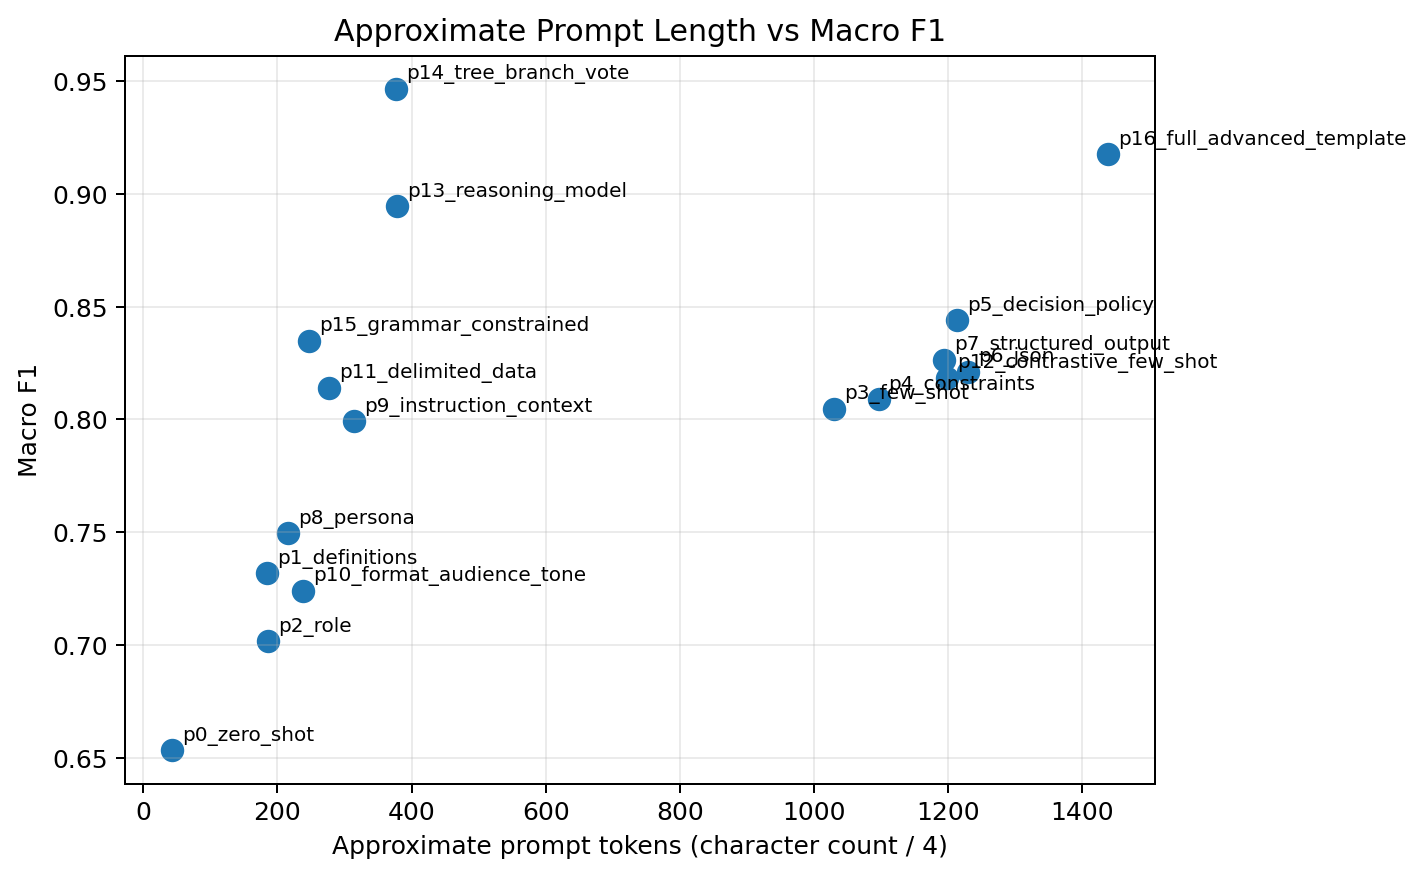

In [11]:
path = PROJECT_ROOT / "07_outputs/reports/figures" / str(summary.iloc[0].get("provider", "mock")) / "20_prompt_length_vs_f1.png"
if path.exists():
    display(Image(filename=str(path)))


## 8. Per-class teljesítmény

A final döntés előtt ellenőrizni kell, hogy a globális score nem rejt-e kritikus class regressziót.

In [12]:
for filename in ["12_per_class_f1_heatmap.png", "13_error_rate_by_class.png"]:
    path = PROJECT_ROOT / "07_outputs/reports/figures" / filename
    if path.exists():
        display(Image(filename=str(path)))


## 9. Multi-objective döntés

Nem készítünk önkényes „magic production score”-t alapértelmezetten, mert a quality/cost/latency súlyok business context nélkül mesterségesek lennének.

Helyette explicit döntési sorrendet használunk:

1. eléri-e a minimum quality szintet?
2. megfelelő-e az output reliability?
3. van-e kritikus class regresszió?
4. mennyi a token/cost overhead?
5. elfogadható-e a P95 latency?
6. egyszerűbb prompt tudja-e ugyanezt?

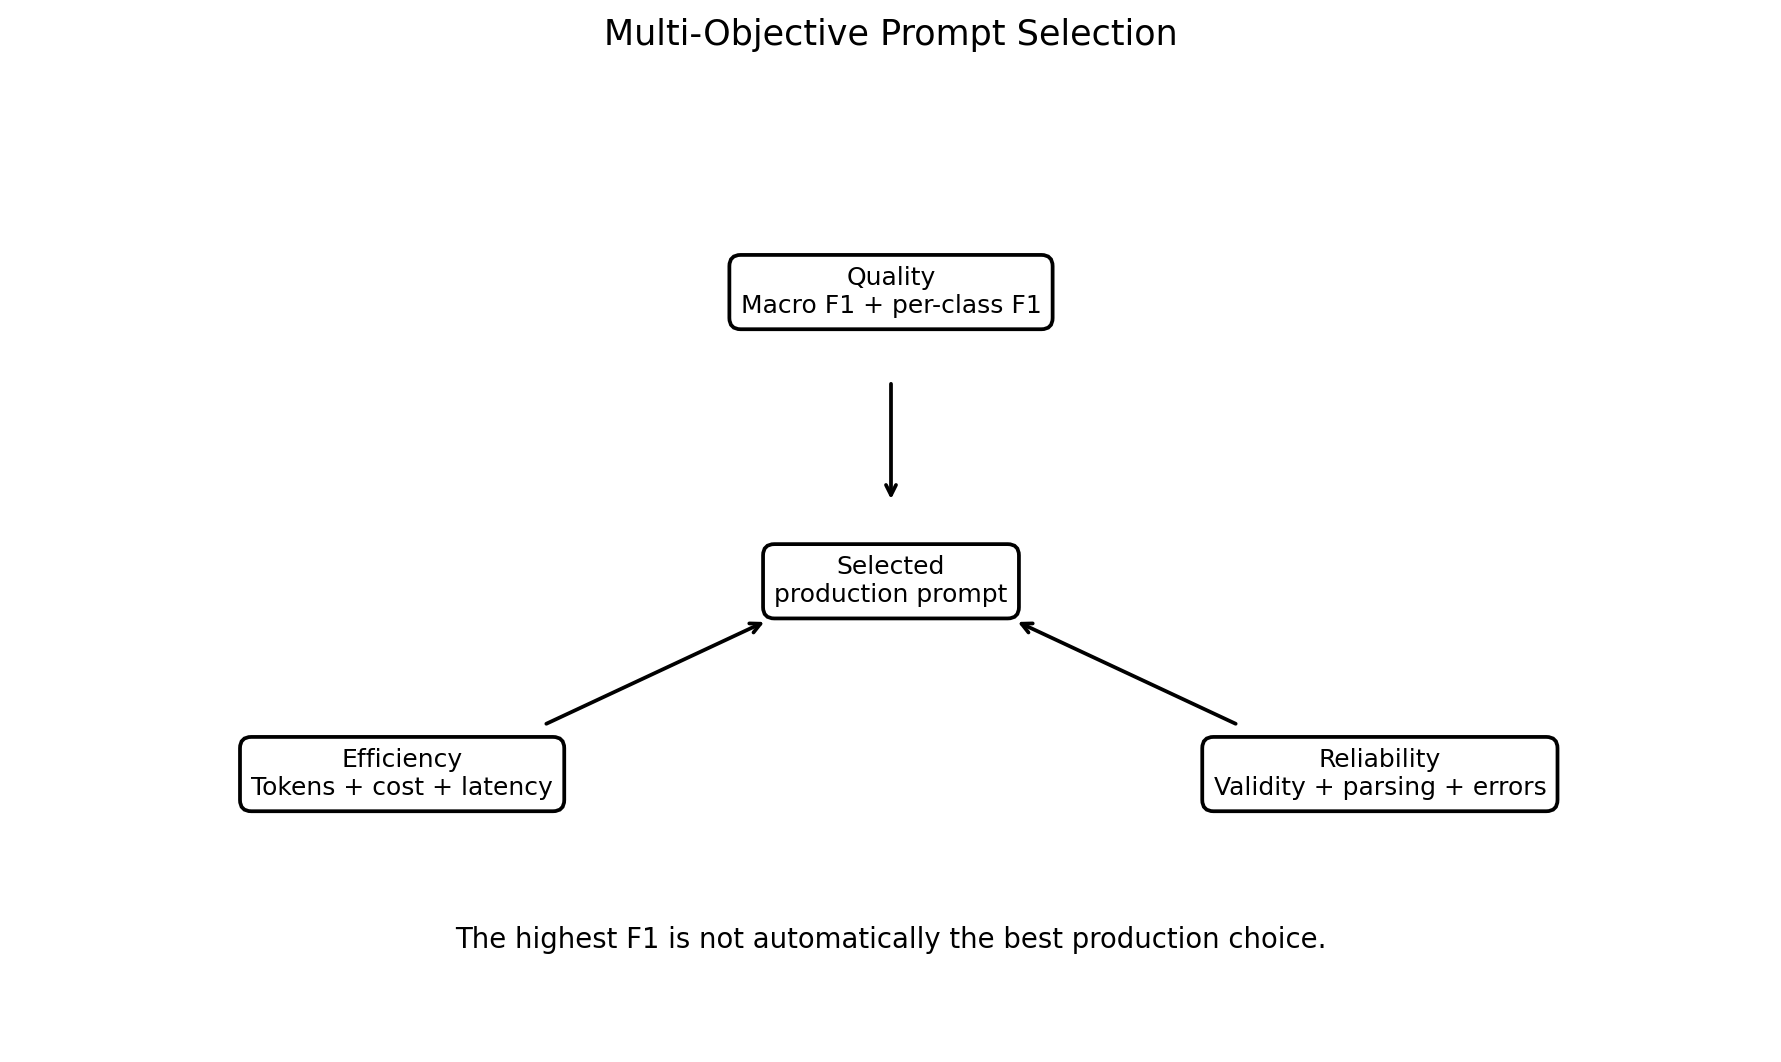

In [13]:
tradeoff_diagram = PROJECT_ROOT / "07_outputs/reports/figures/00d_production_tradeoff.png"
if tradeoff_diagram.exists():
    display(Image(filename=str(tradeoff_diagram)))


## 10. Egyszerű Pareto-dominancia vizsgálat

Egy stratégia **dominált**, ha létezik másik, amely legalább olyan jó qualityt ad, miközben nem drágább, és valamelyik dimenzióban szigorúan jobb.

Ez nem választ automatikusan production promptot, de segít kiszűrni a nehezen indokolható opciókat.

In [14]:
def mark_cost_quality_dominated(frame: pd.DataFrame) -> pd.DataFrame:
    data = frame.copy()
    dominated = []
    for i, row in data.iterrows():
        is_dominated = False
        for j, other in data.iterrows():
            if i == j:
                continue
            at_least_as_good_quality = other["macro_f1"] >= row["macro_f1"]
            no_more_expensive = other["cost_per_1000_requests_usd"] <= row["cost_per_1000_requests_usd"]
            strictly_better_somewhere = (other["macro_f1"] > row["macro_f1"]) or (other["cost_per_1000_requests_usd"] < row["cost_per_1000_requests_usd"])
            if at_least_as_good_quality and no_more_expensive and strictly_better_somewhere:
                is_dominated = True
                break
        dominated.append(is_dominated)
    data["dominated_on_quality_cost"] = dominated
    return data

pareto = mark_cost_quality_dominated(summary)
display(pareto[["strategy", "macro_f1", "cost_per_1000_requests_usd", "dominated_on_quality_cost"]])


,strategy,macro_f1,cost_per_1000_requests_usd,dominated_on_quality_cost
0,p14_tree_branch_vote,0.946599,0.0,False
1,p16_full_advanced_template,0.917515,0.0,True
2,p13_reasoning_model,0.894515,0.0,True
3,p5_decision_policy,0.844015,0.0,True
4,p15_grammar_constrained,0.834862,0.0,True
5,p7_structured_output,0.826353,0.0,True
6,p6_json,0.821044,0.0,True
7,p12_contrastive_few_shot,0.818540,0.0,True
8,p11_delimited_data,0.814141,0.0,True
9,p4_constraints,0.808881,0.0,True


## 11. Final recommendation template

A README-ben a döntést ilyen logikával érdemes megfogalmazni — **csak a valódi API benchmark után**:

> We selected `<strategy>` because it achieved `<Macro F1>` while keeping invalid output at `<rate>`, P95 latency at `<seconds>` and estimated cost at `<USD/1K>`. The higher-complexity alternative `<other>` improved F1 by only `<delta>` but required `<token increase>` more tokens, so it was not selected.

Ez valódi engineering decision, mert quality és operációs trade-off egyszerre jelenik meg.

## 12. Limitations

A korrekt portfólió nem csak az erősségeket sorolja fel.

- egyetlen domain;
- egyetlen primary dataset;
- final benchmark korlátozott mérete;
- LLM API nondeterminism;
- modellverziók idővel változhatnak;
- pricing változhat;
- dataset nem azonos egy valódi vállalati production inboxszal;
- prompt overfitting továbbra is kockázat, ha a holdoutot többször felhasználjuk fejlesztésre.

## 13. Mit bizonyít a kész projekt?

Nem azt, hogy „tudok hosszú promptot írni”, hanem azt, hogy:

**Prompt hypothesis → controlled experiment → row-level logging → objective metrics → uncertainty → error analysis → ablation → cost/latency/reliability trade-off → documented engineering decision.**

A teljes döntési napló a `docs/ENGINEERING_DECISIONS.md` fájlban található.